<a href="https://www.kaggle.com/code/cartelsmith/eda-mosaic-layout?scriptVersionId=329891046" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [33]:
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', palette='bright')
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Causes_Death_Us new.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "willianoliveiragibin/causes-death-us",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

In [34]:
print(df.info())
df.head(15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10868 entries, 0 to 10867
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     10868 non-null  int64  
 1   113 Cause Name           10868 non-null  object 
 2   Cause Name               10868 non-null  object 
 3   State                    10868 non-null  object 
 4   Deaths                   10868 non-null  int64  
 5   Age-adjusted Death Rate  10868 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 509.6+ KB
None


,Year,113 Cause Name,Cause Name,State,Deaths,Age-adjusted Death Rate
0,1999,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,Alabama,2313,52.2
1,1999,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,Alaska,294,55.9
2,1999,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,Arizona,2214,44.8
3,1999,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,Arkansas,1287,47.6
4,1999,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,California,9198,28.7
5,1999,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,Colorado,1519,39.0
6,1999,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,Connecticut,1034,29.3
7,1999,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,Delaware,267,35.3
8,1999,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,District of Columbia,161,28.4
9,1999,"Accidents (unintentional injuries) (V01-X59,Y8...",Unintentional injuries,Florida,5961,35.7


In [35]:
for col in df.columns:
    print(f'Column {col} has {df[col].nunique()} unique values')
    print('--' * 50)

df = df.drop('113 Cause Name', axis = 1)

Column Year has 19 unique values
----------------------------------------------------------------------------------------------------
Column 113 Cause Name has 11 unique values
----------------------------------------------------------------------------------------------------
Column Cause Name has 11 unique values
----------------------------------------------------------------------------------------------------
Column State has 52 unique values
----------------------------------------------------------------------------------------------------
Column Deaths has 5964 unique values
----------------------------------------------------------------------------------------------------
Column Age-adjusted Death Rate has 2490 unique values
----------------------------------------------------------------------------------------------------


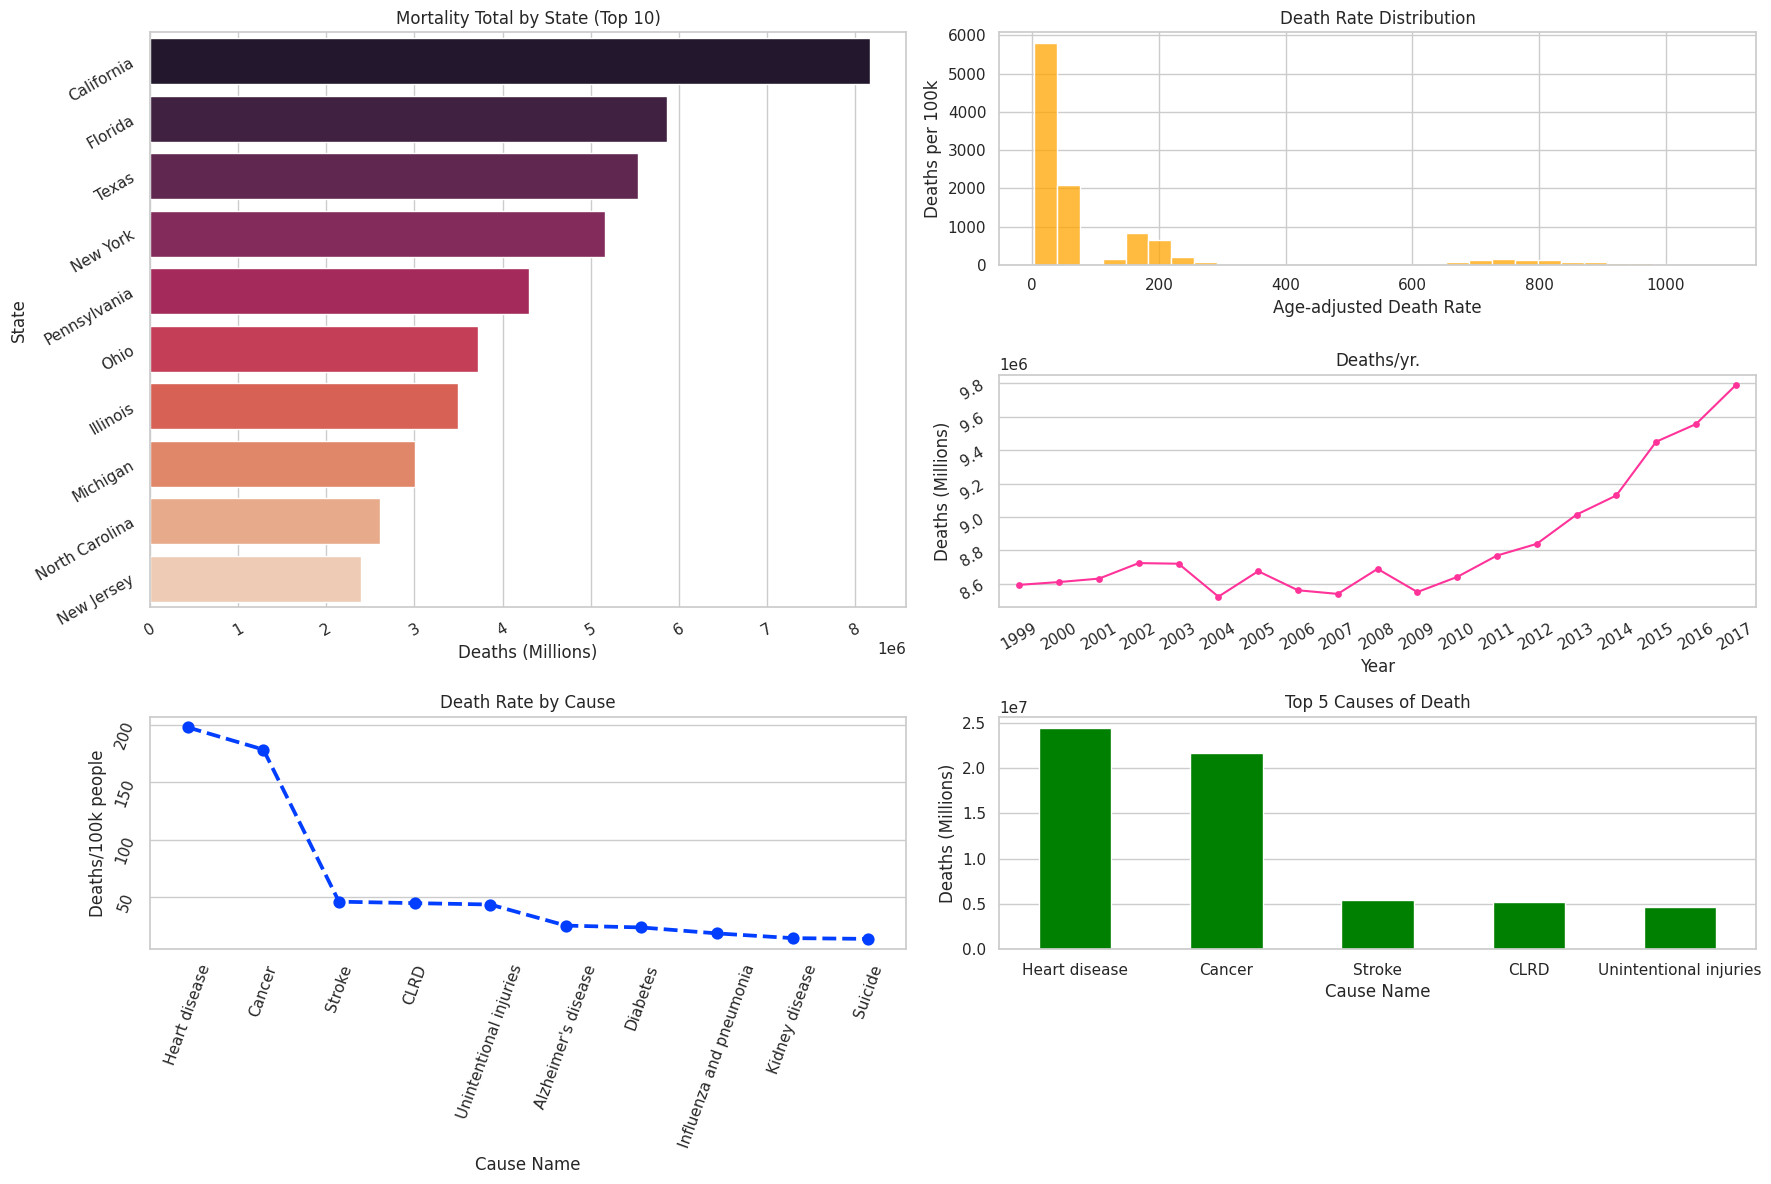

In [36]:
mosaic = [['Top_Left','Top_Right'],
          ['Top_Left','Middle_Right'],
          ['Bottom_Left','Bottom_Right']]

fig, axes = plt.subplot_mosaic(mosaic=mosaic, figsize=(18,12))



# death total by year
death_yearly = df.groupby('Year')['Deaths'].sum().reset_index()

sns.pointplot(death_yearly, x='Year', y="Deaths", color = '#ff3399', ax=axes['Middle_Right'],lw = 1.5)
axes['Middle_Right'].set_title("Deaths/yr.")
axes['Middle_Right'].set_ylabel("Deaths (Millions)")
axes['Middle_Right'].tick_params(rotation = 30)



# Top 5 Causes of Death
top_causes = df.groupby('Cause Name')['Deaths'].sum().nlargest(6).reset_index()
top5_causes = top_causes[1:]

sns.barplot(top5_causes, x='Cause Name', y='Deaths',ax=axes['Bottom_Right'], gap=0.4,color='green',saturation=1)
axes['Bottom_Right'].set_ylabel('Deaths (Millions)')
axes['Bottom_Right'].set_title('Top 5 Causes of Death')

# death total by state
deathcount_states = df.groupby('State')['Deaths'].sum()
top10_deathcount_states = deathcount_states.drop('United States').nlargest(10).reset_index()

sns.barplot(data=top10_deathcount_states, x='Deaths', y='State', ax= axes['Top_Left'], palette='rocket')
axes['Top_Left'].set_xlabel('Deaths (Millions)')
axes['Top_Left'].set_title('Mortality Total by State (Top 10)')
axes['Top_Left'].tick_params(rotation=30)

#Avg Age-Adjusted Death Rate per Cause
avg_rate_per_cause = df.groupby('Cause Name')['Age-adjusted Death Rate'].mean().round(2).sort_values(ascending=False).reset_index()
avg_rate_per_cause = avg_rate_per_cause[1:]

sns.pointplot(avg_rate_per_cause, x='Cause Name', y='Age-adjusted Death Rate', ax=axes['Bottom_Left'],ls='--')
axes['Bottom_Left'].set_ylabel('Deaths/100k people')
axes['Bottom_Left'].set_title('Death Rate by Cause')
axes['Bottom_Left'].tick_params(rotation=70)

#Distribution of Death Rate
sns.histplot(ax=axes['Top_Right'],bins=30, color='orange',data=df['Age-adjusted Death Rate'])
axes['Top_Right'].set_ylabel('Deaths per 100k')
axes['Top_Right'].set_title('Death Rate Distribution')

plt.tight_layout()
plt.show();

In [37]:
#Importing coordinate data for US capitals.
file_path= 'us_state_capitals_lat_lon.csv'
lat_lon_df = lat_lon_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "cartelsmith/us-state-capital-locations-lat-and-lon",
  file_path)

print(lat_lon_df.head())
print(lat_lon_df.head())

#Combining state capital coordinate info with Causes of Death data
print("--"*60)
print(lat_lon_df.head())
print("--"*60)
print(deathcount_states.head())

df_coords_causes = lat_lon_df.merge( deathcount_states, how='left',left_on='State',right_on='State')

x = df_coords_causes['Longitude']
y = df_coords_causes['Latitude']

print("--"*60)

print(f"The shape of 'x' is: {x.shape}")
print(f"The shape of 'y' is: {y.shape}")

        State State_Capital   Latitude   Longitude
0     Alabama    Montgomery  32.361538  -86.279118
1      Alaska        Juneau  58.301935 -134.419740
2     Arizona       Phoenix  33.448457 -112.073844
3    Arkansas   Little Rock  34.746481  -92.289595
4  California    Sacramento  38.581572 -121.494400
        State State_Capital   Latitude   Longitude
0     Alabama    Montgomery  32.361538  -86.279118
1      Alaska        Juneau  58.301935 -134.419740
2     Arizona       Phoenix  33.448457 -112.073844
3    Arkansas   Little Rock  34.746481  -92.289595
4  California    Sacramento  38.581572 -121.494400
------------------------------------------------------------------------------------------------------------------------
        State State_Capital   Latitude   Longitude
0     Alabama    Montgomery  32.361538  -86.279118
1      Alaska        Juneau  58.301935 -134.419740
2     Arizona       Phoenix  33.448457 -112.073844
3    Arkansas   Little Rock  34.746481  -92.289595
4  Californi

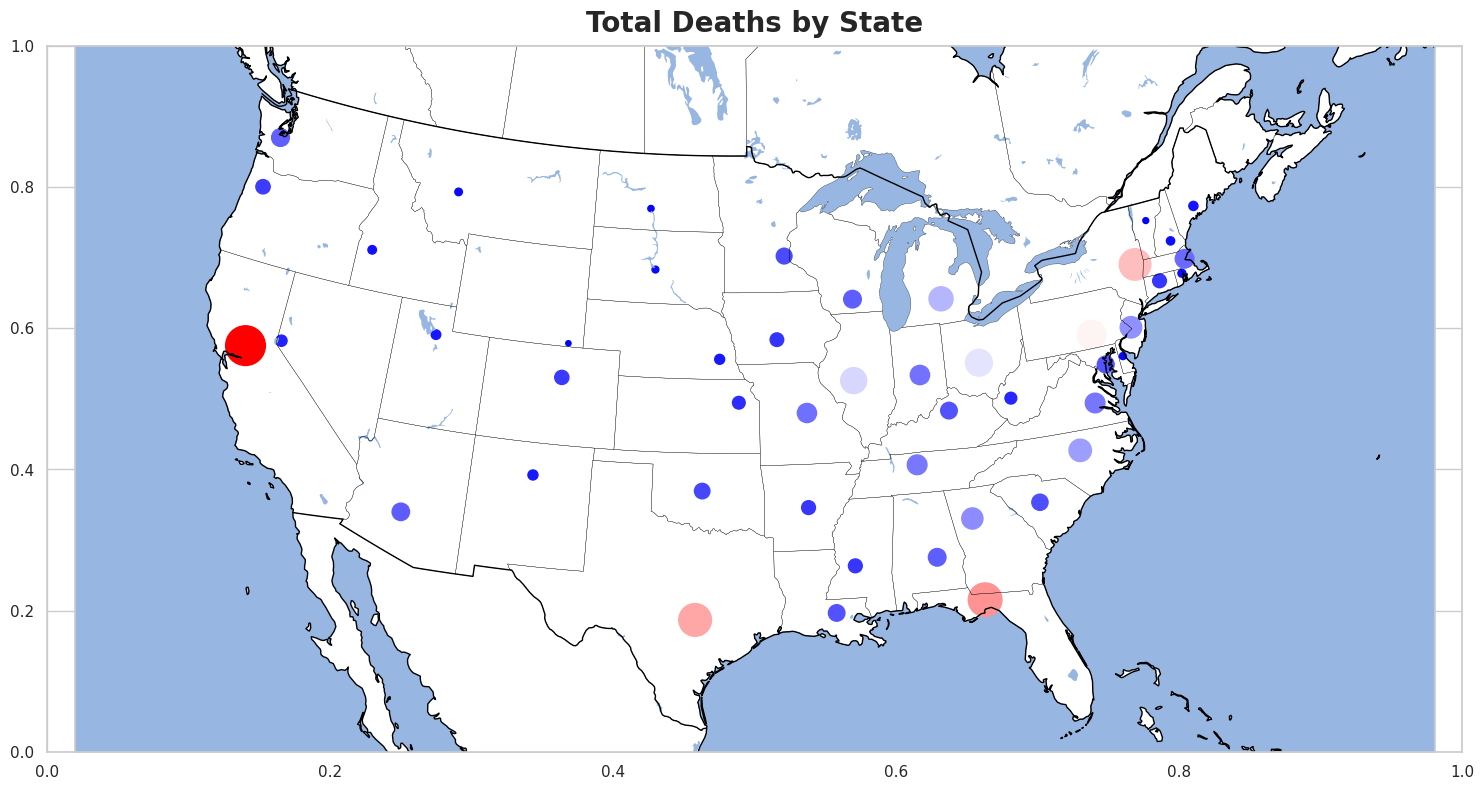

In [38]:
#Plotting Geo Data
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.feature as cfeat

fig = plt.subplots(figsize = (15,8))
ax = plt.axes(projection = ccrs.LambertConformal())
ax.add_feature(cfeat.COASTLINE)
ax.add_feature(cfeat.LAKES)
ax.add_feature(cfeat.BORDERS)
ax.add_feature(cfeat.OCEAN)
ax.add_feature(cfeat.STATES, lw=.2)
ax.set_extent([-125, -65, 25, 50], crs=ccrs.PlateCarree())

ax.scatter(x, y, marker = 'o',transform =ccrs.PlateCarree(),
           s = df_coords_causes['Deaths']/10000, c=df_coords_causes['Deaths'],
           cmap='bwr'
           )
ax.set_title("Total Deaths by State", fontsize=20,pad=10, fontweight = 'bold')
plt.tight_layout()
plt.show()